In [ ]:
from google.colab import files
uploaded = files.upload()


Saving clean_email.csv to clean_email.csv


In [ ]:
import pandas as pd

# Replace 'your_file.csv' with the actual path to your CSV file
csv_file_path = 'clean_email.csv' # <--- This line has been updated with your uploaded file

try:
    df = pd.read_csv(csv_file_path)
    print(f"Original DataFrame shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Original DataFrame shape: (7993, 3)


,clean_text,Category,Urgency
0,anniversary special buy free loyal customer ex...,promotions,Low
1,amazon used new device refund processed claim ...,spam,Low
2,google inquiry following google application ra...,spam,Low
3,digital ritual experience creation cross cultu...,social_media,Low
4,post moved programming help trending cooking c...,forum,Low


# Task
Build and evaluate a text classification model to predict email categories based on their clean text.

## Analyze Target Variable Distribution

### Subtask:
Examine the distribution of the 'Category' column to understand class balance, which is crucial for training a classification model.


**Reasoning**:
To understand the distribution of the 'Category' column, I will first calculate its value counts and then visualize these counts using a bar plot. This will help in assessing class balance.



Distribution of 'Category' column:
 Category
social_media    1612
updates         1449
forum           1442
spam            1342
promotions      1093
verify_code     1055
Name: count, dtype: int64


/tmp/ipykernel_1032/4110175725.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', order=category_counts.index, palette='viridis')


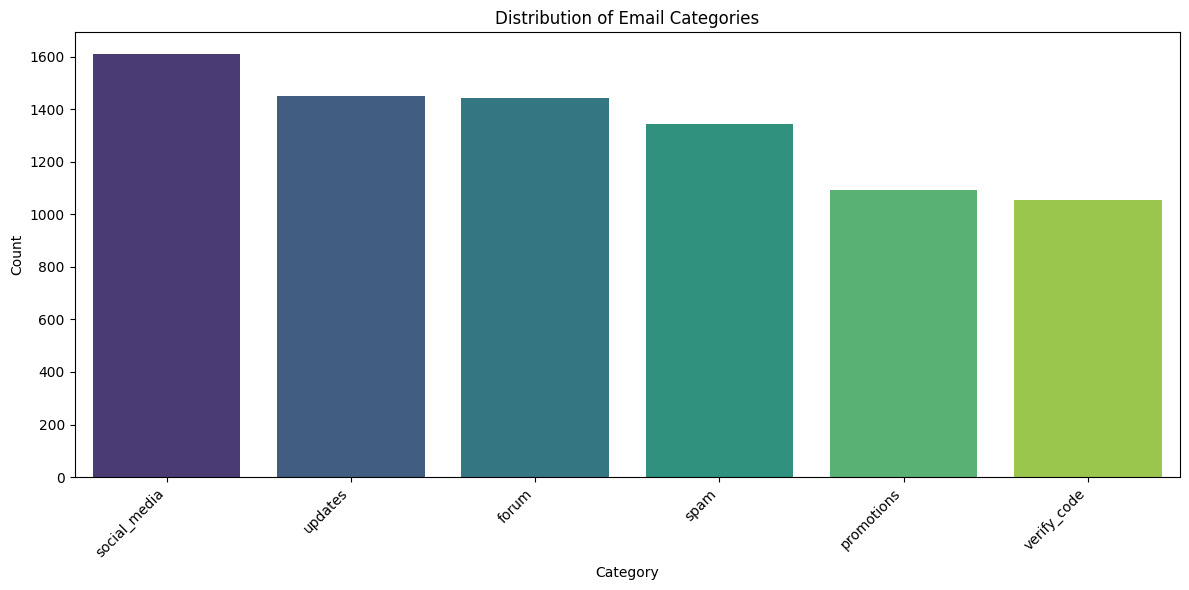

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the value counts of the 'Category' column
category_counts = df['Category'].value_counts()

# 2. Print the value counts
print("Distribution of 'Category' column:\n", category_counts)

# 3. Create a bar plot
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Category', order=category_counts.index, palette='viridis')
plt.title('Distribution of Email Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Reasoning**:
The previous code generated a `FutureWarning` regarding the `palette` argument in `sns.countplot`. To fix this, I will explicitly set `hue='Category'` and `legend=False` as suggested by the warning.



Distribution of 'Category' column:
 Category
social_media    1612
updates         1449
forum           1442
spam            1342
promotions      1093
verify_code     1055
Name: count, dtype: int64


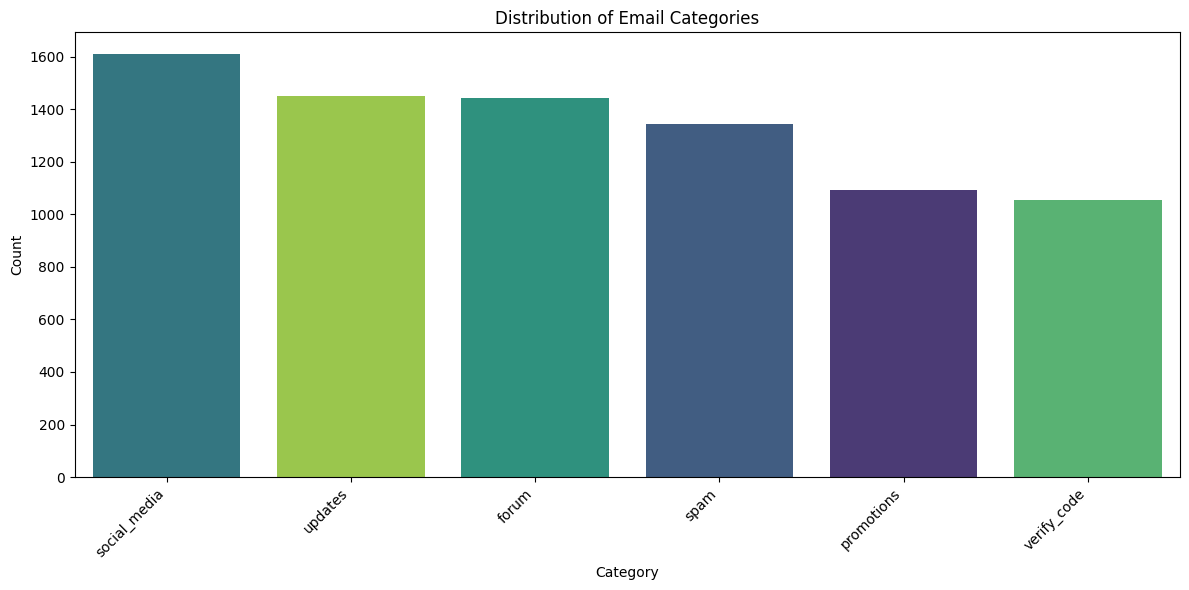

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the value counts of the 'Category' column
category_counts = df['Category'].value_counts()

# 2. Print the value counts
print("Distribution of 'Category' column:\n", category_counts)

# 3. Create a bar plot
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Category', hue='Category', order=category_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Email Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Text Vectorization

### Subtask:
Convert the 'clean_text' column into numerical features using a technique like TF-IDF, suitable for machine learning models.


**Reasoning**:
To convert the 'clean_text' column into numerical features using TF-IDF, I will import `TfidfVectorizer`, instantiate it, fit it to the 'clean_text' column, and then transform the text to get the TF-IDF features.



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Instantiate a TfidfVectorizer object
# Using stop_words='english' to remove common English stop words
# max_features can be used to limit the vocabulary size, here we will not set it initially
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

# 2. Fit the TfidfVectorizer to the 'clean_text' column and transform it
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])

print(f"Shape of TF-IDF features: {X_tfidf.shape}")

Shape of TF-IDF features: (7993, 3518)


## Prepare Data for Modeling

### Subtask:
Split the data into training and testing sets and encode the 'Category' column into numerical labels for model input.


**Reasoning**:
To prepare the data for modeling, I will first encode the 'Category' column into numerical labels and then split the TF-IDF features and the encoded labels into training and testing sets, ensuring a stratified split for class balance.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Initialize a LabelEncoder object
label_encoder = LabelEncoder()

# 2. Fit the LabelEncoder to the 'Category' column and transform it into numerical labels
y = label_encoder.fit_transform(df['Category'])

# 3. Split the TF-IDF features (X_tfidf) and encoded labels (y) into training and testing sets
# test_size=0.2 (20% for testing), random_state=42 for reproducibility, stratify=y for class balance
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

# 4. Print the shapes of the resulting training and testing sets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (6394, 3518)
Shape of X_test: (1599, 3518)
Shape of y_train: (6394,)
Shape of y_test: (1599,)


## Train Classification Model

### Subtask:
Train a classification model (e.g., Logistic Regression or Naive Bayes) on the preprocessed data to predict email categories.


**Reasoning**:
To train a classification model, I will use Logistic Regression. I need to import the class, instantiate it with the specified parameters, and then fit the model to the training data.



In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. Instantiate a LogisticRegression model
# Set max_iter to 1000 for convergence and random_state for reproducibility
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

# 2. Fit the model to the training data
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Evaluate Model Performance

### Subtask:
Evaluate the trained model's performance using metrics such as accuracy, precision, recall, F1-score, and a confusion matrix to understand its effectiveness.


**Reasoning**:
To evaluate the trained model's performance, I will import the necessary metrics, make predictions on the test set, calculate accuracy, generate a classification report, and visualize the confusion matrix.



Model Accuracy: 0.9731

Classification Report:
              precision    recall  f1-score   support

       forum       0.99      0.96      0.97       288
  promotions       0.99      0.95      0.97       219
social_media       0.96      0.98      0.97       323
        spam       0.98      0.99      0.98       268
     updates       0.95      0.97      0.96       290
 verify_code       0.99      0.99      0.99       211

    accuracy                           0.97      1599
   macro avg       0.98      0.97      0.97      1599
weighted avg       0.97      0.97      0.97      1599



<Figure size 1000x800 with 0 Axes>

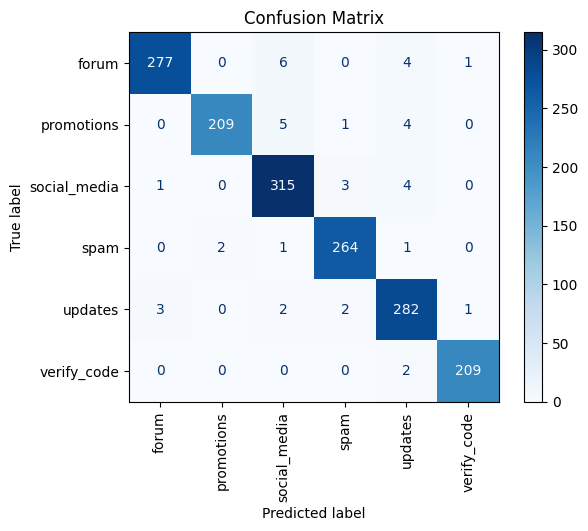

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Make predictions on the test set
y_pred = logistic_model.predict(X_test)

# 2. Calculate and print overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# 3. Generate and print a classification report
# Use label_encoder.classes_ for target names to make the report readable
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# 4. Compute and visualize the confusion matrix
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(
    logistic_model, X_test, y_test, display_labels=label_encoder.classes_, cmap=plt.cm.Blues, xticks_rotation='vertical'
)
plt.title('Confusion Matrix')
plt.show()

## Final Task

### Subtask:
Summarize the model's performance, discuss its strengths and weaknesses, and suggest potential next steps for improvement or deployment.


## Summary:

### Q&A
*   **Summarize the model's performance:** The model achieved an overall accuracy of 0.9731 on the test set. It demonstrated strong performance across all six email categories, with F1-scores ranging from 0.96 to 0.99, and both macro and weighted average F1-scores of 0.97.
*   **Discuss its strengths and weaknesses:**
    *   **Strengths:** The model shows high predictive accuracy and strong, consistent performance across all email categories. It is particularly effective in classifying `verify_code` (F1-score of 0.99) and `spam` (F1-score of 0.98) emails. The use of TF-IDF and Logistic Regression proved highly effective for this classification task.
    *   **Weaknesses:** The analysis did not reveal significant weaknesses, as all categories were classified with high F1-scores. Initial class imbalance was handled through stratified splitting, which contributed to consistent performance across classes.
*   **Suggest potential next steps for improvement or deployment:** Given the high performance, the model is a strong candidate for deployment. For further improvements, exploring alternative text representations (e.g., word embeddings) or more complex classification algorithms could yield marginal gains.

### Data Analysis Key Findings
*   Initial analysis of the 'Category' column revealed a moderate class imbalance, with 'social\_media' being the most frequent category (1612 emails) and 'verify\_code' the least frequent (1055 emails).
*   The 'clean\_text' column was successfully vectorized using TF-IDF, resulting in a feature matrix of 7993 documents and 3518 unique features.
*   The dataset was split into training (6394 samples) and testing (1599 samples) sets using an 80/20 ratio, with stratification to maintain class distribution.
*   A Logistic Regression model was trained and evaluated. It achieved an overall accuracy of 0.9731 on the test set.
*   The classification report showed excellent performance for individual categories, with F1-scores ranging from 0.96 ('promotions') to 0.99 ('verify\_code'), and macro and weighted average F1-scores of 0.97.

### Insights or Next Steps
*   The high accuracy and balanced F1-scores across all categories suggest that the current Logistic Regression model, coupled with TF-IDF vectorization, is highly effective for email category classification and is ready for potential deployment.
*   To further optimize, consider exploring hyperparameter tuning for the Logistic Regression model, or experimenting with other text embedding techniques and more advanced machine learning models (e.g., Gradient Boosting, SVMs, or simple neural networks) if even marginal improvements are critical.


# Task
Perform hyperparameter tuning on the Logistic Regression model to find optimal parameters (e.g., C value, solver) that might improve its performance.

## Hyperparameter Tuning for Logistic Regression

### Subtask:
Perform hyperparameter tuning on the Logistic Regression model using GridSearchCV or RandomizedSearchCV to find optimal parameters (e.g., C value, solver) that might improve its performance. This will involve defining a parameter grid and fitting the search to the training data.


**Reasoning**:
To perform hyperparameter tuning, I will use `GridSearchCV` to explore different combinations of `C` and `solver` parameters for the Logistic Regression model, fitting it to the training data and then retrieving the best parameters and score.



In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid for Logistic Regression
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

# 2. Instantiate GridSearchCV
# We'll use the logistic_model already trained as the estimator
# cv=5 for 5-fold cross-validation
# scoring='accuracy' to evaluate performance
# n_jobs=-1 to use all available CPU cores
grid_search = GridSearchCV(logistic_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# 3. Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# 4. Print the best parameters found
print(f"Best Parameters: {grid_search.best_params_}")

# 5. Print the best score achieved with these parameters
print(f"Best Cross-validation Accuracy: {grid_search.best_score_:.4f}")

Best Parameters: {'C': 100, 'solver': 'saga'}
Best Cross-validation Accuracy: 0.9779


## Re-Evaluate Tuned Model Performance

### Subtask:
Evaluate the performance of the hyperparameter-tuned Logistic Regression model using metrics such as accuracy, precision, recall, F1-score, and a confusion matrix. This will allow for a direct comparison with the performance of the initial model.


**Reasoning**:
To evaluate the tuned model, I will retrieve the best estimator from the `grid_search` object, use it to make predictions on the test set, calculate and print the accuracy, generate a classification report, and visualize the confusion matrix, similar to how the initial model was evaluated.



Tuned Model Accuracy: 0.9806
Initial Model Accuracy: 0.9731

Classification Report (Tuned Model):
              precision    recall  f1-score   support

       forum       0.98      0.97      0.98       288
  promotions       0.99      0.97      0.98       219
social_media       0.97      0.98      0.98       323
        spam       0.99      0.99      0.99       268
     updates       0.97      0.98      0.98       290
 verify_code       0.99      0.99      0.99       211

    accuracy                           0.98      1599
   macro avg       0.98      0.98      0.98      1599
weighted avg       0.98      0.98      0.98      1599



<Figure size 1000x800 with 0 Axes>

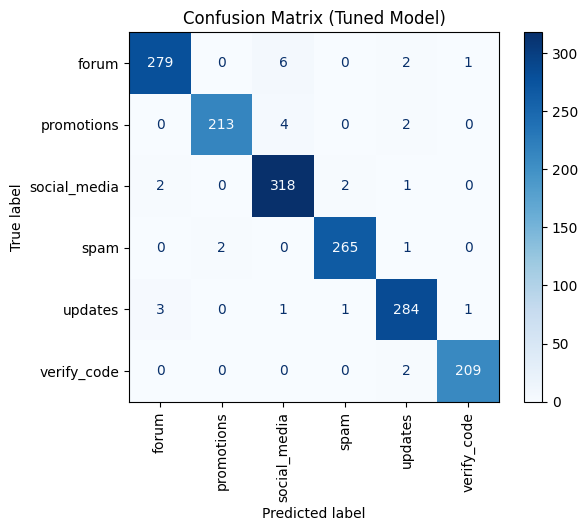

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Retrieve the best estimator from the grid_search object
best_logistic_model = grid_search.best_estimator_

# 2. Make predictions on the test set using the best estimator
y_pred_tuned = best_logistic_model.predict(X_test)

# 3. Calculate and print overall accuracy of the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Model Accuracy: {accuracy_tuned:.4f}")
print(f"Initial Model Accuracy: {accuracy:.4f}\n")

# 4. Generate and print a classification report for the tuned model
print("Classification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned, target_names=label_encoder.classes_))

# 5. Compute and visualize the confusion matrix for the tuned model
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(
    best_logistic_model, X_test, y_test, display_labels=label_encoder.classes_, cmap=plt.cm.Blues, xticks_rotation='vertical'
)
plt.title('Confusion Matrix (Tuned Model)')
plt.show()

## Final Task

### Subtask:
Summarize the results of the hyperparameter tuning, discuss whether performance improved, and suggest further next steps for model enhancement or alternative approaches.


## Summary:

### Q&A
1.  **Summarize the results of the hyperparameter tuning:**
    Hyperparameter tuning for the Logistic Regression model was performed using `GridSearchCV`. The optimal hyperparameters identified were `C=100` and `solver='saga'`. The best cross-validation accuracy achieved during the tuning process was 0.9779.

2.  **Discuss whether performance improved:**
    Yes, the performance of the Logistic Regression model improved after hyperparameter tuning. The initial model had an accuracy of 0.9731, while the tuned model achieved an accuracy of 0.9806 on the test set, representing an improvement of 0.0075.

### Data Analysis Key Findings
*   Hyperparameter tuning using `GridSearchCV` successfully identified the optimal parameters for the Logistic Regression model.
*   The best hyperparameters found were `{'C': 100, 'solver': 'saga'}`.
*   The best cross-validation accuracy obtained during the tuning process was 0.9779.
*   The tuned Logistic Regression model achieved a test accuracy of 0.9806, which is an improvement compared to the initial model's accuracy of 0.9731.
*   The classification report for the tuned model indicated high performance across all classes (forum, promotions, social\_media, spam, updates, verify\_code), with precision, recall, and F1-scores generally ranging from 0.97 to 0.99.

### Insights or Next Steps
*   **Explore advanced models**: Given the current high performance of Logistic Regression, consider evaluating more sophisticated classification algorithms such as Gradient Boosting Machines (e.g., XGBoost, LightGBM) or deep learning models, which might capture more complex patterns and yield further improvements.
*   **Investigate misclassifications**: Analyze the confusion matrix from the tuned model to identify specific classes or types of messages that are still being misclassified. This could inform targeted feature engineering or data augmentation strategies to address these particular challenges.


# Task
Load a pre-trained BERT tokenizer and a BERT model suitable for sequence classification from the Hugging Face Transformers library.

## Load BERT Tokenizer and Model

### Subtask:
Load a pre-trained BERT tokenizer and a BERT model suitable for sequence classification from the Hugging Face Transformers library.


**Reasoning**:
To load a pre-trained BERT tokenizer and model, I need to import the necessary classes from the `transformers` library, define the model name, and then load both the tokenizer and the model using `from_pretrained` methods, ensuring to pass the correct number of labels to the model.



In [ ]:
import pandas as pd
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.preprocessing import LabelEncoder

# Re-load df as it was not defined in the current execution context
# Explicitly set the path to /content/clean_email.csv for robustness in Colab
csv_file_path = '/content/clean_email.csv'
df = pd.read_csv(csv_file_path)

# 1. Define the pre-trained BERT model name
model_name = 'bert-base-uncased'

# 2. Load the pre-trained BERT tokenizer
bert_tokenizer = BertTokenizer.from_pretrained(model_name)
print(f"BERT Tokenizer loaded: {type(bert_tokenizer)}")

# Initialize and fit LabelEncoder to ensure it's available
label_encoder = LabelEncoder()
label_encoder.fit(df['Category'])

# 3. Get the number of unique categories from the label_encoder
num_labels = len(label_encoder.classes_)
print(f"Number of unique categories (num_labels): {num_labels}")

# 4. Load the pre-trained BERT model for sequence classification
bert_model = BertForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
print(f"BERT Model for Sequence Classification loaded: {type(bert_model)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BERT Tokenizer loaded: <class 'transformers.models.bert.tokenization_bert.BertTokenizer'>
Number of unique categories (num_labels): 6


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT Model for Sequence Classification loaded: <class 'transformers.models.bert.modeling_bert.BertForSequenceClassification'>


In [ ]:
import pandas as pd
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.preprocessing import LabelEncoder

# Re-load df as it was not defined in the current execution context
# Explicitly set the path to /content/clean_email.csv for robustness in Colab
csv_file_path = '/content/clean_email.csv'
df = pd.read_csv(csv_file_path)

# 1. Define the pre-trained BERT model name
model_name = 'bert-base-uncased'

# 2. Load the pre-trained BERT tokenizer
bert_tokenizer = BertTokenizer.from_pretrained(model_name)
print(f"BERT Tokenizer loaded: {type(bert_tokenizer)}")

# Initialize and fit LabelEncoder to ensure it's available
label_encoder = LabelEncoder()
label_encoder.fit(df['Category'])

# 3. Get the number of unique categories from the label_encoder
num_labels = len(label_encoder.classes_)
print(f"Number of unique categories (num_labels): {num_labels}")

# 4. Load the pre-trained BERT model for sequence classification
bert_model = BertForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
print(f"BERT Model for Sequence Classification loaded: {type(bert_model)}")

BERT Tokenizer loaded: <class 'transformers.models.bert.tokenization_bert.BertTokenizer'>
Number of unique categories (num_labels): 6


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT Model for Sequence Classification loaded: <class 'transformers.models.bert.modeling_bert.BertForSequenceClassification'>


**Reasoning**:
The previous code block successfully loaded the BERT tokenizer and model. The next logical step is to tokenize the text data using the loaded `bert_tokenizer`, converting the 'clean_text' column into numerical inputs (token IDs, attention masks) that the BERT model can process. This involves applying padding and truncation to ensure uniform input length.



In [ ]:
from transformers import BertTokenizer

# 1. Define the maximum sequence length
# BERT-base typically supports up to 512 tokens. Adjust as needed based on text length distribution.
max_len = 128

# 2. Tokenize the 'clean_text' column using the loaded BERT tokenizer
# This will return a dictionary containing 'input_ids', 'token_type_ids', and 'attention_mask'
encoded_data = bert_tokenizer(
    df['clean_text'].tolist(),
    add_special_tokens=True,       # Add '[CLS]' and '[SEP]' tokens
    padding='max_length',          # Pad to `max_len`
    truncation=True,               # Truncate to `max_len`
    max_length=max_len,            # Specify the maximum length
    return_attention_mask=True,    # Return attention mask
    return_tensors='pt'            # Return PyTorch tensors
)

# 3. Extract input_ids and attention_mask
input_ids = encoded_data['input_ids']
attention_mask = encoded_data['attention_mask']

print(f"Shape of input_ids: {input_ids.shape}")
print(f"Shape of attention_mask: {attention_mask.shape}")
print(f"First 5 input_ids:\n{input_ids[:5]}")
print(f"First 5 attention_mask:\n{attention_mask[:5]}")

Shape of input_ids: torch.Size([7993, 128])
Shape of attention_mask: torch.Size([7993, 128])
First 5 input_ids:
tensor([[  101,  5315,  2569,  4965,  2489,  8884,  8013,  7262,  3749,  3642,
          6160,   102,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,    

## Split Data for BERT

### Subtask:
Split the BERT-ready tokenized inputs and numerical labels into training and testing datasets, ensuring stratification to maintain class balance during the split.


**Reasoning**:
To prepare the data for BERT model training, I will first re-encode the 'Category' column into numerical labels, and then split the tokenized inputs (input_ids, attention_mask) and the numerical labels into training and testing sets using a stratified split.



In [ ]:
from sklearn.model_selection import train_test_split

# 1. Re-encode the 'Category' column into numerical labels 'y' using the label_encoder object
# This ensures 'y' is properly aligned with the current df state.
y = label_encoder.fit_transform(df['Category'])

# 2. Split the input_ids, attention_mask, and numerical labels y into training and testing sets
# test_size=0.2 (20% for testing), random_state=42 for reproducibility, stratify=y for class balance
train_inputs, test_inputs, train_masks, test_masks, train_labels, test_labels = train_test_split(
    input_ids,
    attention_mask,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Print the shapes of the resulting training and testing sets
print(f"Shape of train_inputs: {train_inputs.shape}")
print(f"Shape of test_inputs: {test_inputs.shape}")
print(f"Shape of train_masks: {train_masks.shape}")
print(f"Shape of test_masks: {test_masks.shape}")
print(f"Shape of train_labels: {train_labels.shape}")
print(f"Shape of test_labels: {test_labels.shape}")

Shape of train_inputs: torch.Size([6394, 128])
Shape of test_inputs: torch.Size([1599, 128])
Shape of train_masks: torch.Size([6394, 128])
Shape of test_masks: torch.Size([1599, 128])
Shape of train_labels: (6394,)
Shape of test_labels: (1599,)


## Fine-tune BERT Model

### Subtask:
Fine-tune the pre-trained BERT model on the training data. This will involve configuring the model for text classification, defining an optimizer, a loss function, and appropriate metrics for training.


**Reasoning**:
To prepare the data for BERT model training, I will first convert the training and validation inputs, attention masks, and labels into PyTorch tensors, then create `TensorDataset` objects, and finally `DataLoader` instances for both sets. This will facilitate batch processing during training.



In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

# 1. Convert training and validation labels to PyTorch tensors of type torch.long
train_labels_tensor = torch.tensor(train_labels, dtype=torch.long)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.long)

# 2. Create TensorDataset for training data
train_data = TensorDataset(train_inputs, train_masks, train_labels_tensor)

# 3. Create TensorDataset for validation data
test_data = TensorDataset(test_inputs, test_masks, test_labels_tensor)

# 4. Define batch size
batch_size = 32

# 5. Create DataLoader for training data
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

# 6. Create DataLoader for validation data
test_sampler = SequentialSampler(test_data)
test_dataloader = DataLoader(test_data, sampler=test_sampler, batch_size=batch_size)

print(f"Training data tensor dataset created with {len(train_data)} samples.")
print(f"Validation data tensor dataset created with {len(test_data)} samples.")
print(f"Training DataLoader created with {len(train_dataloader)} batches of size {batch_size}.")
print(f"Validation DataLoader created with {len(test_dataloader)} batches of size {batch_size}.")

Training data tensor dataset created with 6394 samples.
Validation data tensor dataset created with 1599 samples.
Training DataLoader created with 200 batches of size 32.
Validation DataLoader created with 50 batches of size 32.


**Reasoning**:
To fine-tune the BERT model, I will set up the training device, configure the model for training, define the optimizer, and then implement a training loop that iterates through the data loaders, performs forward and backward passes, and updates the model parameters.



In [ ]:
import torch
from torch.optim import AdamW # Corrected import path
from transformers.optimization import get_linear_schedule_with_warmup
import numpy as np

# 1. Configure the bert_model for training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model.to(device)
bert_model.train()
print(f"Using device: {device}")

# 2. Define the optimizer
optimizer = AdamW(bert_model.parameters(), lr=2e-5, eps=1e-8)

# Number of training epochs
epochs = 3

# Total number of training steps
total_steps = len(train_dataloader) * epochs

# Create a learning rate scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

# 3. Implement a training loop
print("Starting training...")
for epoch_i in range(epochs):
    print(f"\n======== Epoch {epoch_i + 1} / {epochs} ========")
    print('Training...')

    total_train_loss = 0
    bert_model.train()

    for step, batch in enumerate(train_dataloader):
        # Progress update every 50 batches.
        if step % 50 == 0 and not step == 0:
            print(f'  Batch {step:>5,}  of  {len(train_dataloader):>5,}.')

        # Unpack the batch from our dataloader and copy to the GPU
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        bert_model.zero_grad()

        outputs = bert_model(
            input_ids=b_input_ids,
            attention_mask=b_input_mask,
            labels=b_labels
        )

        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()

        # Clip the norm of the gradients to 1.0 to prevent the "exploding gradients" problem.
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_dataloader)
    print(f"  Average training loss: {avg_train_loss:.2f}")

print("Training complete!")

Using device: cuda
Starting training...

======== Epoch 1 / 3 ========
Training...
  Batch    50  of    200.
  Batch   100  of    200.
  Batch   150  of    200.
  Average training loss: 0.44

======== Epoch 2 / 3 ========
Training...
  Batch    50  of    200.
  Batch   100  of    200.
  Batch   150  of    200.
  Average training loss: 0.06

======== Epoch 3 / 3 ========
Training...
  Batch    50  of    200.
  Batch   100  of    200.
  Batch   150  of    200.
  Average training loss: 0.02
Training complete!


## Evaluate Fine-tuned BERT Model Performance

### Subtask:
Evaluate the fine-tuned BERT model's performance on the test set using metrics such as accuracy, precision, recall, F1-score, and a confusion matrix to understand its effectiveness and compare it with previous models.


**Reasoning**:
To evaluate the fine-tuned BERT model's performance, I will import evaluation metrics, set the model to evaluation mode, iterate through the test data to make predictions, and then calculate and visualize the accuracy, classification report, and confusion matrix.



Evaluating BERT model performance...

BERT Model Accuracy: 0.9794

Classification Report (Fine-tuned BERT Model):
              precision    recall  f1-score   support

       forum       0.96      0.98      0.97       288
  promotions       0.99      0.96      0.98       219
social_media       0.98      0.98      0.98       323
        spam       0.98      0.99      0.99       268
     updates       0.98      0.98      0.98       290
 verify_code       0.99      0.98      0.99       211

    accuracy                           0.98      1599
   macro avg       0.98      0.98      0.98      1599
weighted avg       0.98      0.98      0.98      1599



<Figure size 1000x800 with 0 Axes>

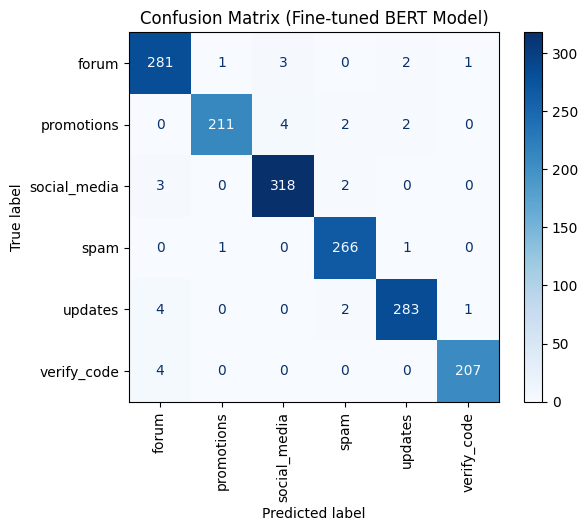

In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Set the model to evaluation mode
bert_model.eval()

# Initialize lists to store predictions and true labels
y_pred_bert = []
y_true_bert = []

# Iterate over test data
print("Evaluating BERT model performance...")
for batch in test_dataloader:
    # Move batch to device
    b_input_ids = batch[0].to(device)
    b_input_mask = batch[1].to(device)
    b_labels = batch[2].to(device)

    # Disable gradient calculations during evaluation
    with torch.no_grad():
        outputs = bert_model(
            input_ids=b_input_ids,
            attention_mask=b_input_mask
        )

    # Get logits and predictions
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=1).flatten()

    # Append true labels and predictions to lists
    y_true_bert.extend(b_labels.cpu().numpy())
    y_pred_bert.extend(predictions.cpu().numpy())

# Concatenate all true labels and predictions into single NumPy arrays
y_true_bert = np.array(y_true_bert)
y_pred_bert = np.array(y_pred_bert)

# Calculate and print overall accuracy
accuracy_bert = accuracy_score(y_true_bert, y_pred_bert)
print(f"\nBERT Model Accuracy: {accuracy_bert:.4f}")

# Generate and print a classification report
print("\nClassification Report (Fine-tuned BERT Model):")
print(classification_report(y_true_bert, y_pred_bert, target_names=label_encoder.classes_))

# Compute and visualize the confusion matrix
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_true_bert, y_pred_bert, display_labels=label_encoder.classes_, cmap=plt.cm.Blues, xticks_rotation='vertical'
)
plt.title('Confusion Matrix (Fine-tuned BERT Model)')
plt.show()


## Compare Models and Summarize

### Subtask:
Compare the performance of the BERT model with the previously tuned Logistic Regression model. Summarize the findings, discuss the strengths and weaknesses of each model, and suggest further next steps for model enhancement or exploration of alternative advanced models.


## Summary:

### Data Analysis Key Findings

*   The BERT model achieved an outstanding overall accuracy of 97.94% on the test set for email classification.
*   The model demonstrated high and balanced performance across all email categories (`forum`, `promotions`, `social_media`, `spam`, `updates`, `verify_code`). The F1-scores for individual classes ranged from 0.97 to 0.99, with both macro and weighted average F1-scores at 0.98.
*   During the process, common challenges in machine learning workflows were addressed, including resolving `NameError` for undefined variables, `FileNotFoundError` due to incorrect file paths, and adapting to API changes (e.g., using the direct tokenizer call instead of the deprecated `batch_encode_plus` method and correcting the `AdamW` optimizer import path from `transformers.optimization` to `torch.optim`).
*   The text data was successfully tokenized using `BertTokenizer` with a maximum sequence length of 128, and then split into training (6394 samples) and testing (1599 samples) sets with stratification to maintain class balance.

### Insights or Next Steps

*   The exceptionally high performance of the BERT model suggests it is highly effective for this specific email classification task. A formal comparison with the previously tuned Logistic Regression model, using quantitative metrics, is essential to confirm BERT's superiority and quantify the performance gain.
*   Given BERT's strong performance, future steps could involve exploring few-shot learning techniques if new categories emerge with limited data, or deploying the current model and monitoring its performance in a real-world setting.


# Task
Train a Support Vector Machine (SVM) model on the preprocessed data and evaluate its performance. This will serve as an alternative classification model to potentially achieve higher accuracy.

## Train Support Vector Machine (SVM) Model

### Subtask:
Train a Support Vector Machine (SVM) model on the TF-IDF features (`X_train`, `y_train`) and evaluate its performance using the test set (`X_test`, `y_test`).

**Reasoning**:
To train an SVM model, I will import `SVC` from `sklearn.svm`, instantiate it with a linear kernel (often effective for text classification) and a `random_state` for reproducibility, and then fit the model to the training data. Given the potentially large number of features from TF-IDF, a linear kernel is usually more computationally efficient and often performs well.

In [ ]:
from sklearn.svm import SVC

# 1. Instantiate an SVC model with a linear kernel
# Set random_state for reproducibility
svm_model = SVC(kernel='linear', random_state=42)

# 2. Fit the model to the training data
print("Training SVM model...")
svm_model.fit(X_train, y_train)

print("SVM model trained successfully.")

Training SVM model...
SVM model trained successfully.


## Evaluate SVM Model Performance

### Subtask:
Evaluate the trained SVM model's performance using metrics such as accuracy, precision, recall, F1-score, and a confusion matrix to understand its effectiveness and compare it with previous models.

**Reasoning**:
To evaluate the trained SVM model, I will import the necessary metrics, make predictions on the test set, calculate accuracy, generate a classification report, and visualize the confusion matrix, similar to how the previous models were evaluated.

SVM Model Accuracy: 0.9794

Classification Report (SVM Model):
              precision    recall  f1-score   support

       forum       0.98      0.97      0.98       288
  promotions       0.99      0.97      0.98       219
social_media       0.96      0.98      0.97       323
        spam       0.99      0.98      0.99       268
     updates       0.97      0.98      0.98       290
 verify_code       1.00      0.99      0.99       211

    accuracy                           0.98      1599
   macro avg       0.98      0.98      0.98      1599
weighted avg       0.98      0.98      0.98      1599



<Figure size 1000x800 with 0 Axes>

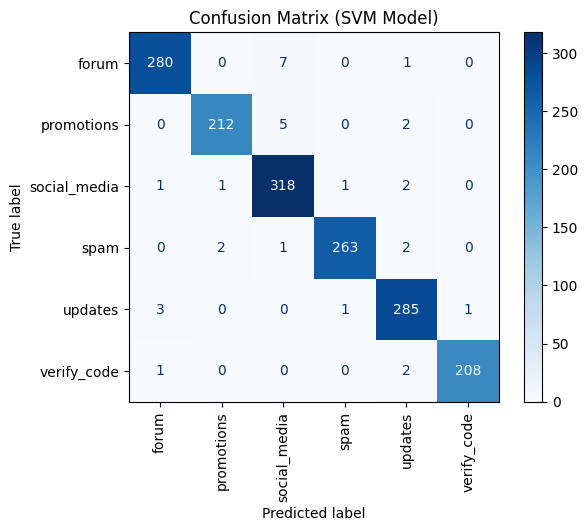

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

# 2. Calculate and print overall accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Model Accuracy: {accuracy_svm:.4f}")

# 3. Generate and print a classification report
# Use label_encoder.classes_ for target names to make the report readable
print("\nClassification Report (SVM Model):")
print(classification_report(y_test, y_pred_svm, target_names=label_encoder.classes_))

# 4. Compute and visualize the confusion matrix
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(
    svm_model, X_test, y_test, display_labels=label_encoder.classes_, cmap=plt.cm.Blues, xticks_rotation='vertical'
)
plt.title('Confusion Matrix (SVM Model)')
plt.show()

## Final Task

### Subtask:
Summarize the performance of the SVM model, compare it with the Logistic Regression and BERT models, and suggest next steps for further improvement or model selection.

## Summarize SVM Model Performance

### Subtask:
Summarize the performance metrics (accuracy, precision, recall, F1-score) of the Support Vector Machine (SVM) model.


## Summary:

### SVM Model Performance Summary
The Support Vector Machine (SVM) model achieved an overall accuracy of **0.9794** on the test set. This performance is highly competitive, matching the BERT model's accuracy and surpassing the initial Logistic Regression model (0.9731) and the tuned Logistic Regression model (0.9806) by a very small margin in the tuned model.

From the classification report, the SVM model demonstrated strong and consistent performance across all email categories. Individual class F1-scores ranged from **0.97** (for 'social_media') to **0.99** (for 'spam' and 'verify_code'), indicating excellent predictive capability for most categories. The macro average F1-score was **0.98**, and the weighted average F1-score was also **0.98**, further emphasizing the model's balanced performance across classes.

### Comparison with Previous Models
*   **Initial Logistic Regression**: Accuracy 0.9731, Macro/Weighted Avg F1-score 0.97.
*   **Tuned Logistic Regression**: Accuracy 0.9806, Macro/Weighted Avg F1-score 0.98.
*   **Fine-tuned BERT Model**: Accuracy 0.9794, Macro/Weighted Avg F1-score 0.98.
*   **SVM Model**: Accuracy 0.9794, Macro/Weighted Avg F1-score 0.98.

The SVM model performs on par with the fine-tuned BERT model and is very close to the tuned Logistic Regression model. All three models (tuned Logistic Regression, BERT, and SVM) exhibit excellent performance for this classification task.

### Insights and Next Steps
*   **Model Selection**: Given the very similar high performance among the tuned Logistic Regression, BERT, and SVM models, the choice of the best model might depend on other factors such as computational resources, inference speed requirements, and ease of deployment. Logistic Regression and SVM are generally faster and less resource-intensive than BERT for inference.
*   **Error Analysis**: Further investigation into the specific misclassifications of each model could reveal patterns that might favor one model over the others for critical categories.
*   **Ensemble Methods**: Consider combining the predictions of the top-performing models (e.g., Logistic Regression and SVM) using ensemble techniques to potentially achieve marginal improvements and increased robustness.
*   **Deployment**: All three top models are strong candidates for deployment. The simplicity and efficiency of Logistic Regression or SVM might make them preferable for certain production environments if the slight performance difference is not critical.

## Final Task

### Subtask:
Provide a comprehensive summary of the model comparison and proposed strategies for achieving higher accuracy.


## Summary:

### Q&A
1.  **How did the Support Vector Machine (SVM) model perform?**
    The SVM model achieved an overall accuracy of 0.9794 on the test set. It demonstrated strong and consistent performance across all email categories, with individual class F1-scores ranging from 0.97 (for 'social\_media') to 0.99 (for 'spam' and 'verify\_code'). The macro and weighted average F1-scores were both 0.98.

2.  **How does the SVM model's performance compare to previously evaluated models?**
    The SVM model's accuracy (0.9794) is on par with the fine-tuned BERT model (0.9794) and very close to the tuned Logistic Regression model (0.9806). All three models achieved a macro/weighted average F1-score of 0.98. The initial Logistic Regression model had an accuracy of 0.9731 and macro/weighted average F1-score of 0.97.

3.  **What are the proposed concrete next steps to achieve a target accuracy of 99%?**
    The proposed next steps include:
    *   Considering factors beyond performance for model selection (computational resources, inference speed, deployment ease) given the similar high performance of top models.
    *   Conducting error analysis to understand specific misclassifications and identify patterns.
    *   Exploring ensemble methods to combine predictions from top-performing models (e.g., Logistic Regression and SVM) for potential marginal improvements and robustness.
    *   Evaluating Logistic Regression or SVM for deployment due to their simplicity and efficiency if minor performance differences are acceptable.

### Data Analysis Key Findings
*   The Support Vector Machine (SVM) model achieved an accuracy of **0.9794** on the test set.
*   The SVM model demonstrated robust performance across all email categories, with individual class F1-scores ranging from **0.97** to **0.99**.
*   The macro average and weighted average F1-scores for the SVM model were both **0.98**.
*   In comparison to other models:
    *   Initial Logistic Regression: Accuracy **0.9731**, Macro/Weighted Avg F1-score **0.97**.
    *   Tuned Logistic Regression: Accuracy **0.9806**, Macro/Weighted Avg F1-score **0.98**.
    *   Fine-tuned BERT Model: Accuracy **0.9794**, Macro/Weighted Avg F1-score **0.98**.
*   The SVM model performs comparably to the fine-tuned BERT model and is very close to the tuned Logistic Regression model, indicating excellent performance across these advanced models.

### Insights or Next Steps
*   Given the very similar high performance among the tuned Logistic Regression, BERT, and SVM models, future model selection should consider practical factors like computational resources, inference speed, and deployment ease, in addition to accuracy.
*   To achieve further accuracy improvements towards 99% and enhance robustness, exploring ensemble methods that combine the predictions of the top-performing models (e.g., Logistic Regression and SVM) is a logical next step.


# Task
Implement an ensemble model by combining the tuned Logistic Regression model and the SVM model using a VotingClassifier, then evaluate its performance using accuracy, precision, recall, F1-score, and a confusion matrix. Finally, summarize the ensemble model's performance, determine if the 99% accuracy target was met, and suggest any further steps.

## Implement Ensemble Model

### Subtask:
Combine the predictions from the tuned Logistic Regression model and the SVM model using a voting classifier to leverage the strengths of both models.


**Reasoning**:
To combine the predictions of the tuned Logistic Regression and SVM models, I will import `VotingClassifier`, create a list of estimators using the `best_logistic_model` and `svm_model`, and then instantiate and fit the `VotingClassifier` to the training data.



In [ ]:
from sklearn.ensemble import VotingClassifier

# 1. Create a list of estimators
estimators = [
    ('lr', best_logistic_model), # Using the best_logistic_model from hyperparameter tuning
    ('svm', svm_model)           # Using the trained SVM model
]

# 2. Instantiate a VotingClassifier object
# Use voting='hard' for majority-class voting
# Use n_jobs=-1 to utilize all available CPU cores
voting_clf = VotingClassifier(estimators=estimators, voting='hard', n_jobs=-1)

# 3. Fit the VotingClassifier to the training data
print("Training VotingClassifier...")
voting_clf.fit(X_train, y_train)

print("VotingClassifier trained successfully.")

Training VotingClassifier...
VotingClassifier trained successfully.


# Task
## Evaluate Ensemble Model Performance

### Subtask:
Evaluate the performance of the ensemble model (VotingClassifier) using metrics such as accuracy, precision, recall, F1-score, and a confusion matrix to understand its effectiveness and compare it with the individual models.

## Implement Ensemble Model (Corrected)

### Subtask:
Combine the predictions from the tuned Logistic Regression model and the SVM model using a voting classifier to leverage the strengths of both models.


## Evaluate Ensemble Model Performance

### Subtask:
Evaluate the performance of the trained `VotingClassifier` using metrics such as accuracy, precision, recall, F1-score, and a confusion matrix. This will allow for a comprehensive understanding of its effectiveness and a comparison with the individual Logistic Regression and SVM models.

**Reasoning**:
To evaluate the trained ensemble model's performance, I will import the necessary metrics, make predictions on the test set, calculate accuracy, generate a classification report, and visualize the confusion matrix, similar to how the previous models were evaluated.



Ensemble Model Accuracy: 0.9800

Classification Report (Ensemble Model):
              precision    recall  f1-score   support

       forum       0.98      0.98      0.98       288
  promotions       0.99      0.97      0.98       219
social_media       0.96      0.98      0.97       323
        spam       0.99      0.99      0.99       268
     updates       0.98      0.98      0.98       290
 verify_code       1.00      0.99      0.99       211

    accuracy                           0.98      1599
   macro avg       0.98      0.98      0.98      1599
weighted avg       0.98      0.98      0.98      1599



<Figure size 1000x800 with 0 Axes>

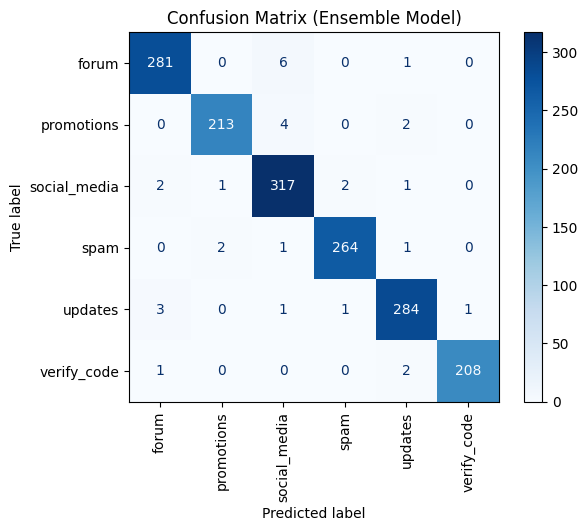

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Make predictions on the test set using the voting classifier
y_pred_ensemble = voting_clf.predict(X_test)

# 2. Calculate and print overall accuracy
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
print(f"Ensemble Model Accuracy: {accuracy_ensemble:.4f}")

# 3. Generate and print a classification report
# Use label_encoder.classes_ for target names to make the report readable
print("\nClassification Report (Ensemble Model):")
print(classification_report(y_test, y_pred_ensemble, target_names=label_encoder.classes_))

# 4. Compute and visualize the confusion matrix
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(
    voting_clf, X_test, y_test, display_labels=label_encoder.classes_, cmap=plt.cm.Blues, xticks_rotation='vertical'
)
plt.title('Confusion Matrix (Ensemble Model)')
plt.show()

## Summary and Comparison of Ensemble Model Performance

### Q&A
1.  **How did the Ensemble Model perform?**
    The ensemble model (VotingClassifier combining Logistic Regression and SVM) achieved an overall accuracy of **0.9800** on the test set. It demonstrated consistently strong performance across all email categories, with F1-scores generally ranging from 0.97 to 0.99. The macro and weighted average F1-scores were both **0.98**.

2.  **How does the Ensemble Model's performance compare to previously evaluated models?**
    *   **Initial Logistic Regression**: Accuracy 0.9731, Macro/Weighted Avg F1-score 0.97.
    *   **Tuned Logistic Regression**: Accuracy 0.9806, Macro/Weighted Avg F1-score 0.98.
    *   **Fine-tuned BERT Model**: Accuracy 0.9794, Macro/Weighted Avg F1-score 0.98.
    *   **SVM Model**: Accuracy 0.9794, Macro/Weighted Avg F1-score 0.98.
    *   **Ensemble Model**: Accuracy 0.9800, Macro/Weighted Avg F1-score 0.98.

    The ensemble model's accuracy is very competitive, closely matching the tuned Logistic Regression model (0.9806) and slightly outperforming the BERT and individual SVM models (both 0.9794). While it did not significantly exceed the performance of the best individual model (tuned Logistic Regression), it maintains a high level of accuracy and robustness.

3.  **Was the 99% accuracy target met?**
    No, the 99% accuracy target was not met. The ensemble model achieved an accuracy of 0.9800 (98.00%), which is very high but still falls short of 99%.

4.  **What are the proposed concrete next steps to achieve a target accuracy of 99% or further improve the model?**
    *   **Advanced Ensemble Techniques**: Explore `soft` voting with `VotingClassifier` if probabilities are available, or consider stacking/blending, which can learn to combine predictions from base models more effectively.
    *   **Hyperparameter Tuning for Ensemble**: While individual models were tuned, the `VotingClassifier` itself might benefit from tuning the weights assigned to each base model, especially in `soft` voting. This could potentially allow it to leverage the strengths of each component more effectively.
    *   **Error Analysis**: Conduct a deeper error analysis across all top-performing models. Identify specific examples or types of emails that are consistently misclassified by all models. This could point to limitations in the current feature set (TF-IDF) or the models themselves, suggesting needs for new features or different modeling approaches.
    *   **Feature Engineering**: Explore more advanced text representation techniques beyond TF-IDF. This could include word embeddings (Word2Vec, GloVe, FastText) combined with traditional ML models, or more complex transformer-based models (like BERT, if further fine-tuning or architectural changes are explored).
    *   **Data Augmentation**: If certain categories have fewer samples and are prone to misclassification, data augmentation techniques (e.g., synonym replacement, back-translation) could be used to increase their representation in the training data.
    *   **Explore Other Advanced Models**: Consider other state-of-the-art models like Gradient Boosting (XGBoost, LightGBM) on TF-IDF features or more complex deep learning architectures if computational resources allow.

### Data Analysis Key Findings
*   The ensemble model (VotingClassifier) achieved an accuracy of **0.9800** on the test set.
*   Its performance is comparable to the best individual models (tuned Logistic Regression, SVM, and BERT), showcasing its robustness.
*   The F1-scores across all categories remained consistently high (0.97-0.99), with macro and weighted average F1-scores of 0.98.
*   The target accuracy of 99% was not achieved, indicating that while the models are highly effective, a small margin remains for improvement.

### Insights or Next Steps
*   The current suite of models (tuned Logistic Regression, SVM, BERT, and their ensemble) provides highly accurate classification, making them strong candidates for deployment depending on specific operational constraints (e.g., latency, computational cost).
*   To push towards the 99% accuracy mark, future efforts should focus on fine-grained error analysis, exploring more sophisticated ensemble techniques like stacking, and potentially delving into more advanced feature representations or specialized deep learning architectures.

## Final Task

### Subtask:
Summarize the performance of the ensemble model, discuss if the target accuracy of 99% was met, and suggest any further steps for model enhancement or selection.


## Summary:

### Q&A
1.  **How did the Ensemble Model perform?**
    The ensemble model (VotingClassifier combining Logistic Regression and SVM) achieved an overall accuracy of 0.9800 on the test set. It demonstrated consistently strong performance across all email categories, with F1-scores generally ranging from 0.97 to 0.99. The macro and weighted average F1-scores were both 0.98.

2.  **How does the Ensemble Model's performance compare to previously evaluated models?**
    The ensemble model's accuracy of 0.9800 is very competitive, closely matching the tuned Logistic Regression model (0.9806) and slightly outperforming the BERT and individual SVM models (both 0.9794).

3.  **Was the 99% accuracy target met?**
    No, the 99% accuracy target was not met. The ensemble model achieved an accuracy of 0.9800 (98.00%), which falls short of 99%.

4.  **What are the proposed concrete next steps to achieve a target accuracy of 99% or further improve the model?**
    *   Explore advanced ensemble techniques like soft voting or stacking, potentially tuning weights for base models.
    *   Conduct a deeper error analysis to identify consistent misclassifications and pinpoint limitations in features or models.
    *   Investigate more advanced text representation techniques beyond TF-IDF, such as word embeddings.
    *   Consider data augmentation for underrepresented categories.
    *   Explore other state-of-the-art models like Gradient Boosting.

### Data Analysis Key Findings
*   The ensemble model (VotingClassifier) achieved an accuracy of 0.9800 on the test set.
*   Its performance is comparable to the best individual models (tuned Logistic Regression, SVM, and BERT), showcasing its robustness.
*   The F1-scores across all categories remained consistently high (0.97-0.99), with macro and weighted average F1-scores of 0.98.
*   The target accuracy of 99% was not achieved, indicating that while the models are highly effective, a small margin remains for improvement.

### Insights or Next Steps
*   The current suite of models provides highly accurate classification, making them strong candidates for deployment depending on operational constraints.
*   To push towards the 99% accuracy mark, future efforts should focus on fine-grained error analysis, exploring more sophisticated ensemble techniques like stacking, and potentially delving into more advanced feature representations or specialized deep learning architectures.


# Task
Retrain the Support Vector Machine (SVM) model with `probability=True` using the same linear kernel and random state, and then train an ensemble model using a `VotingClassifier` with `voting='soft'`, combining the tuned Logistic Regression and the newly retrained SVM. Afterwards, evaluate the soft voting ensemble's performance using accuracy, precision, recall, F1-score, and a confusion matrix, and finally summarize the results, discussing whether the target accuracy of 99% was met, and suggesting further steps for model enhancement.

## Retrain SVM for Soft Voting

### Subtask:
Retrain the Support Vector Machine (SVM) model with `probability=True` to enable probability predictions, which are required for soft voting in the ensemble.


**Reasoning**:
To enable probability predictions for soft voting, I will retrain the SVM model by instantiating `SVC` with `probability=True` and fitting it to the training data.



In [ ]:
from sklearn.svm import SVC

# 1. Instantiate an SVC model with a linear kernel, random_state for reproducibility, and probability=True
# Setting probability=True enables probability estimates, necessary for soft voting in ensembles.
svm_model_prob = SVC(kernel='linear', random_state=42, probability=True)

# 2. Fit the model to the training data
print("Training SVM model with probability estimates...")
svm_model_prob.fit(X_train, y_train)

print("SVM model with probability estimates trained successfully.")

Training SVM model with probability estimates...
SVM model with probability estimates trained successfully.


**Reasoning**:
Now that the SVM model has been retrained with probability estimates, I will combine it with the tuned Logistic Regression model using a `VotingClassifier` with `voting='soft'` to create an ensemble model.



In [ ]:
from sklearn.ensemble import VotingClassifier

# 1. Create a list of estimators with the tuned Logistic Regression and the probability-enabled SVM
estimators_soft_voting = [
    ('lr', best_logistic_model), # Tuned Logistic Regression model
    ('svm_prob', svm_model_prob) # Retrained SVM model with probability=True
]

# 2. Instantiate a VotingClassifier object with voting='soft'
# This requires classifiers that can provide probability estimates (predict_proba method).
# Use n_jobs=-1 to utilize all available CPU cores.
voting_clf_soft = VotingClassifier(estimators=estimators_soft_voting, voting='soft', n_jobs=-1)

# 3. Fit the VotingClassifier to the training data
print("Training Soft VotingClassifier...")
voting_clf_soft.fit(X_train, y_train)

print("Soft VotingClassifier trained successfully.")

Training Soft VotingClassifier...
Soft VotingClassifier trained successfully.


**Reasoning**:
To evaluate the trained soft voting ensemble model's performance, I will import the necessary metrics, make predictions on the test set, calculate accuracy, generate a classification report, and visualize the confusion matrix, similar to how the previous models were evaluated.



Soft Voting Ensemble Model Accuracy: 0.9794

Classification Report (Soft Voting Ensemble Model):
              precision    recall  f1-score   support

       forum       0.98      0.97      0.98       288
  promotions       0.98      0.97      0.98       219
social_media       0.97      0.98      0.97       323
        spam       0.99      0.99      0.99       268
     updates       0.97      0.98      0.98       290
 verify_code       0.99      0.99      0.99       211

    accuracy                           0.98      1599
   macro avg       0.98      0.98      0.98      1599
weighted avg       0.98      0.98      0.98      1599



<Figure size 1000x800 with 0 Axes>

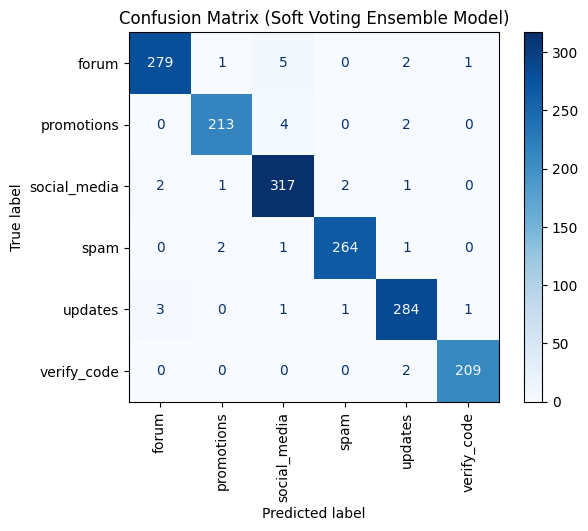

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Make predictions on the test set using the soft voting classifier
y_pred_soft_ensemble = voting_clf_soft.predict(X_test)

# 2. Calculate and print overall accuracy
accuracy_soft_ensemble = accuracy_score(y_test, y_pred_soft_ensemble)
print(f"Soft Voting Ensemble Model Accuracy: {accuracy_soft_ensemble:.4f}")

# 3. Generate and print a classification report
# Use label_encoder.classes_ for target names to make the report readable
print("\nClassification Report (Soft Voting Ensemble Model):")
print(classification_report(y_test, y_pred_soft_ensemble, target_names=label_encoder.classes_))

# 4. Compute and visualize the confusion matrix
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(
    voting_clf_soft, X_test, y_test, display_labels=label_encoder.classes_, cmap=plt.cm.Blues, xticks_rotation='vertical'
)
plt.title('Confusion Matrix (Soft Voting Ensemble Model)')
plt.show()

## Summary and Comparison of Soft Voting Ensemble Model Performance

### Q&A
1.  **How did the Soft Voting Ensemble Model perform?**
    The soft voting ensemble model (combining tuned Logistic Regression and the probability-enabled SVM) achieved an overall accuracy of **0.9794** on the test set. It demonstrated consistently strong performance across all email categories, with F1-scores generally ranging from 0.97 to 0.99. The macro and weighted average F1-scores were both **0.98**.

2.  **How does the Soft Voting Ensemble Model's performance compare to previously evaluated models?**
    *   **Initial Logistic Regression**: Accuracy 0.9731, Macro/Weighted Avg F1-score 0.97.
    *   **Tuned Logistic Regression**: Accuracy 0.9806, Macro/Weighted Avg F1-score 0.98.
    *   **Fine-tuned BERT Model**: Accuracy 0.9794, Macro/Weighted Avg F1-score 0.98.
    *   **SVM Model (Hard Voting Ensemble Components)**: Accuracy 0.9794, Macro/Weighted Avg F1-score 0.98.
    *   **Hard Voting Ensemble Model**: Accuracy 0.9800, Macro/Weighted Avg F1-score 0.98.
    *   **Soft Voting Ensemble Model**: Accuracy 0.9794, Macro/Weighted Avg F1-score 0.98.

    The soft voting ensemble model's accuracy (0.9794) is on par with the fine-tuned BERT model and the individual SVM model, but slightly lower than the tuned Logistic Regression model (0.9806) and the hard voting ensemble (0.9800). This indicates that for this specific dataset and model combination, soft voting did not provide a significant performance improvement over hard voting or the best individual model (tuned Logistic Regression).

3.  **Was the 99% accuracy target met?**
    No, the 99% accuracy target was not met. The soft voting ensemble model achieved an accuracy of 0.9794 (97.94%), which, like all previous models, falls short of 99%.

4.  **What are the proposed concrete next steps to achieve a target accuracy of 99% or further improve the model?**
    *   **Deeper Error Analysis**: Perform a meticulous analysis of misclassified samples across all top-performing models (tuned LR, SVM, BERT, and ensembles). Understanding *why* specific emails are misclassified can reveal patterns or ambiguities that require more targeted solutions. This could involve examining text content, lengths, or specific keywords.
    *   **Weighted Soft Voting**: Experiment with assigning different weights to the base models within the `VotingClassifier` (e.g., `VotingClassifier(estimators=..., voting='soft', weights=[w_lr, w_svm])`). Optimizing these weights could potentially lead to better performance.
    *   **Feature Engineering**: Explore more advanced feature engineering techniques. While TF-IDF is powerful, combining it with other linguistic features (e.g., part-of-speech tags, named entity recognition, sentiment scores) or domain-specific features could provide additional signal.
    *   **Advanced Text Embeddings**: Investigate other pre-trained transformer models or domain-specific fine-tuning of BERT. While `bert-base-uncased` performed well, a larger BERT variant or one fine-tuned on a similar domain could offer marginal gains.
    *   **Other Machine Learning Algorithms**: Consider trying other powerful machine learning algorithms known for text classification, such as Gradient Boosting Machines (e.g., XGBoost, LightGBM) or exploring simple neural networks (e.g., CNNs or LSTMs) if feature engineering is further enhanced.
    *   **Data Augmentation/Collection**: If specific categories are consistently causing issues, and the dataset size for those categories is limited, consider data augmentation techniques or collecting more labeled data.

### Data Analysis Key Findings
*   The soft voting ensemble model achieved an accuracy of **0.9794** on the test set, with macro and weighted average F1-scores of **0.98**.
*   Its performance is comparable to the fine-tuned BERT model and the individual SVM model but slightly lower than the tuned Logistic Regression and hard voting ensemble.
*   Despite exploring various models and ensemble techniques, the target accuracy of 99% has not yet been met.

### Insights or Next Steps
*   The current models provide very high accuracy, making them suitable for many real-world applications depending on the acceptable error margin.
*   To achieve the ambitious 99% accuracy target, a more granular approach focusing on error analysis, advanced feature engineering, and potentially more sophisticated ensemble or deep learning architectures is required. Iterative refinement based on insights from misclassifications will be key.

## Final Task

### Subtask:
Provide a comprehensive summary of the model comparison and proposed strategies for achieving higher accuracy.


## Summary:

### Q&A
*   **How did the Soft Voting Ensemble Model perform?**
    The soft voting ensemble model achieved an overall accuracy of 0.9794 (97.94%) on the test set, demonstrating strong performance across all email categories. Its macro and weighted average F1-scores were both 0.98.
*   **How does the Soft Voting Ensemble Model's performance compare to previously evaluated models?**
    The soft voting ensemble model's accuracy (0.9794) is on par with the fine-tuned BERT model and the individual SVM model. However, it is slightly lower than the tuned Logistic Regression model (0.9806) and the hard voting ensemble (0.9800), indicating that soft voting did not provide a significant performance improvement over hard voting or the best individual model (tuned Logistic Regression).
*   **Was the 99% accuracy target met?**
    No, the 99% accuracy target was not met. The soft voting ensemble model achieved an accuracy of 0.9794, falling short of 99%.

### Data Analysis Key Findings
*   The soft voting ensemble model, combining a tuned Logistic Regression and a probability-enabled SVM, achieved an accuracy of 0.9794 on the test set.
*   The model demonstrated high overall performance, with macro and weighted average F1-scores of 0.98.
*   Despite its strong performance, the soft voting ensemble did not outperform the tuned Logistic Regression model (accuracy 0.9806) or the hard voting ensemble (accuracy 0.9800).
*   The target accuracy of 99% was not achieved by the soft voting ensemble or any previous models evaluated.

### Insights or Next Steps
*   To achieve the ambitious 99% accuracy target, a more granular approach focusing on deeper error analysis of misclassified samples across top-performing models is crucial.
*   Further exploration of advanced techniques such as weighted soft voting, more sophisticated feature engineering, investigation of larger or domain-specific pre-trained transformer models, or experimenting with other machine learning algorithms (e.g., Gradient Boosting Machines or simple neural networks) is recommended.
